## Import Libraries

In [2]:
import os
import json 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

## Load Dataset

In [3]:
DATASET_PATH="/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

metadata_path=os.path.join(DATASET_PATH,"HAM10000_metadata.csv")
df=pd.read_csv(metadata_path)

df.shape

(10015, 7)

In [4]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## Explore Class Distribution

Class Distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


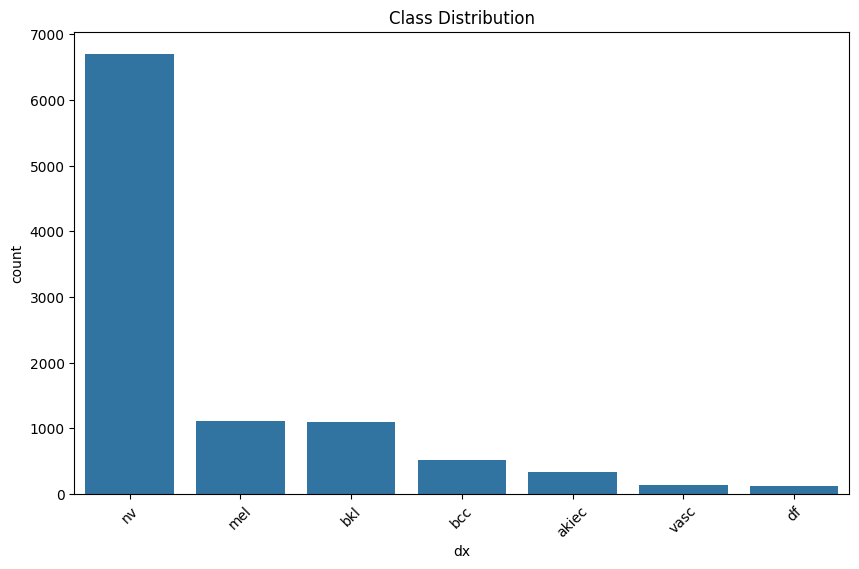

In [10]:
print("Class Distribution:")
print(df['dx'].value_counts())

plt.figure(figsize=(10,6))
sns.countplot(data=df,x='dx', order=df['dx'].value_counts().index)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

## Map Image Paths

In [14]:
image_paths=[]

for root,dirs,files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".jpg"):
            image_paths.append(os.path.join(root,file))
print("Total iamges found:",len(image_paths))


# Map image_id -> full path
imageid_path_dict={
    os.path.splitext(os.path.basename(path))[0]: path
    for path in image_paths
}

df['image_path']=df['image_id'].map(imageid_path_dict)

#check for missing images
print("Missing image paths:",df['image_path'].isnull().sum())


Total iamges found: 20030
Missing image paths: 0


## Encode Labels

In [17]:
le=LabelEncoder()
df['label']=le.fit_transform(df['dx'])

class_names=list(le.classes_)
num_classes=len(class_names)

print("Classes:",class_names)
print("Names of classes:",num_classes)

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Names of classes: 7


## Stratified Train/Val/Test Split

In [19]:
train_df,temp_df=train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df,test_df=train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Train:",train_df.shape)
print("Validation:", val_df.shape)
print("Test:",test_df.shape)

Train: (7010, 9)
Validation: (1502, 9)
Test: (1503, 9)


## Save Processed Files

In [20]:
WORKING_DIR="/kaggle/working/"

train_df.to_csv(os.path.join(WORKING_DIR,"train.csv"),index=False)
val_df.to_csv(os.path.join(WORKING_DIR,"val.csv"),index=False)
test_df.to_csv(os.path.join(WORKING_DIR, "test.csv"), index=False)

#save class name
with open(os.path.join(WORKING_DIR,"class_names.json"),"w") as f:
    json.dump(class_names,f)
print("CSV files and class names saved successfully")

CSV files and class names saved successfully
